In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from math import log10 as lg

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

In [50]:
file_name = 'optimal_design.xlsx'
file_name = 'DOE.xlsx'


In [51]:
# 读取数据
df = pd.read_excel(file_name)
df = df.drop(columns=df.columns[0])  # 删除第一列
df.columns = [col[0] for col in df.columns]


In [52]:
df = df.drop_duplicates().reset_index(drop=True)
df

,A,B,C,D,E,F
0,-1,-1,-1,-1,-1,-1
1,1,-1,-1,-1,-1,1
2,-1,1,-1,-1,-1,1
3,1,1,-1,-1,-1,-1
4,-1,-1,1,-1,-1,1
5,1,-1,1,-1,-1,-1
6,-1,1,1,-1,-1,-1
7,1,1,1,-1,-1,1
8,-1,-1,-1,1,-1,1
9,1,-1,-1,1,-1,-1


In [53]:
# 配置参数
factors = len(df.columns)
n_experiments = len(df)


In [54]:
factors,n_experiments

(6, 32)

In [55]:
# 编辑关心的效应

# 考虑主效应、二阶交互效应
complete_factors = 2

# 不考虑主效应，只考虑与完全因子的二阶交互效应
semi_factors = 1

# 只考虑主效应，不考虑与完全因子的二阶交互效应
main_factors = 0

# 其余：考虑主效应，只考虑与完全因子的二阶交互效应

# complete_factors,other,semi_factors,main_factors

In [56]:
def effects_X(design_df):
    # 复制原始数据
    result_df = design_df.copy()
    
    # 存储交互效应列
    interaction_dfs = []
    
    # 生成交互效应列
    for k in range(complete_factors):
        factor_k = design_df.columns[k]
        for i in range(k+1, factors-main_factors):
            factor_i = design_df.columns[i]
            # 创建交互效应列，列名格式为 "因子1:因子2"
            interaction_name = f"{factor_k}{factor_i}"
            interaction_col = design_df[factor_k] * design_df[factor_i]
            interaction_dfs.append(pd.DataFrame({interaction_name: interaction_col}))
    
    # 合并所有交互效应列
    if interaction_dfs:
        interaction_df = pd.concat(interaction_dfs, axis=1)
        # 合并主效应和交互效应
        result_df = pd.concat([
            pd.DataFrame({'(I)': np.ones(n_experiments,dtype=int)}), 
            result_df.iloc[:, :factors-semi_factors-main_factors], 
            result_df.iloc[:,factors-main_factors:], 
            interaction_df], axis=1)
    else:
        # 如果没有交互效应，只包含主效应
        result_df = pd.concat([
            pd.DataFrame({'(I)': np.ones(n_experiments,dtype=int)}), 
            result_df.iloc[:, :factors-semi_factors-main_factors], 
            result_df.iloc[:,factors-main_factors:]
            ], axis=1)
    
    return result_df


In [57]:
X_df = effects_X(df)
cols_effects = X_df.columns
n_effects = len(X_df.iloc[0])

In [58]:
X = X_df.to_numpy()
np.linalg.det(X.T @ X)/n_experiments**len(X_df.iloc[0])

1.0000000000000049

In [59]:
# 计算相关系数矩阵
mu = X.mean(axis=0)
mu[0] = 0
X_diff = X - mu
s = X_diff.std(axis=0)
s[0] = 1
cov_matrix = X_diff.T @ X_diff / (n_experiments)
corr_matrix = cov_matrix / np.outer(s, s)

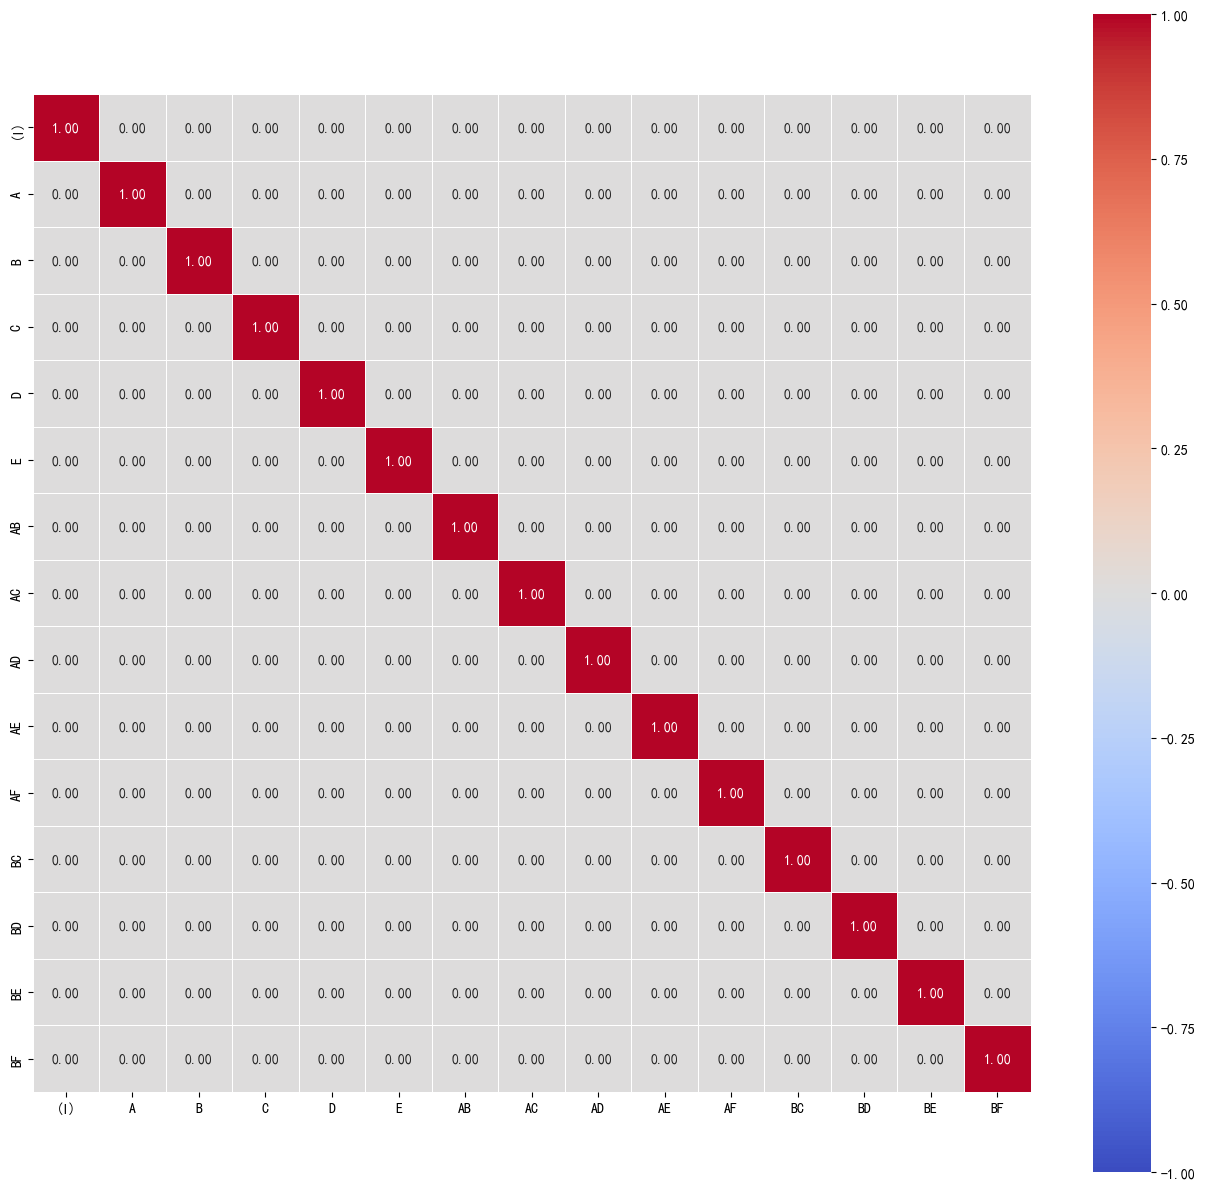

In [60]:
# 估计相关系数矩阵
corr_matrix = X.T @ X / n_experiments

# 绘制热力图，使用列名作为坐标轴标签
plt.figure(figsize=(13, 12))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    # cmap="Blues",
    cmap="coolwarm",  # 使用发散型颜色映射，区分正负相关

    vmin=-1,
    vmax=1,
    
    square=True,
    linewidths=0.5,
    xticklabels=cols_effects,  
    yticklabels=cols_effects   
)

plt.tight_layout()
plt.show()
